# Individual Assignment I – Machine Learning Foundations

**Student:** Lara Iglesias  
**Repository:** ML-fundamentals-2026  
**Model:** Logistic Regression

## **Introduction**

This assignment focuses on data preparation and feature engineering using the UCI Bank Marketing dataset. The dataset contains information about direct marketing campaigns conducted by a Portuguese banking institution.

The objective of these campaigns was to determine whether a client would subscribe to a term deposit after being contacted by the bank. Therefore, this is a supervised learning problem in which the goal is to predict a binary outcome (subscription: yes or no).

The primary focus of this assignment is not to build a highly accurate predictive model, but to correctly prepare the data so that a reliable machine learning pipeline can be built. 

## Task Ordering: 

Before starting the implementation of the project, I defined a clear general structure of the order of the steps to follow. Establishing the sequence of steps prior to the implementation ensured that the data preparation followed the best practices in machine learning and maintained a logical consistency through the analysis. While some modifications were made through the development of the project, the overall pipeline was planned beforehand. 

## Exploratory Data Anlaysis:

The first thing I performed was an initial exploratory data analysis to understand the dataset. The first step in any process of data curation should be inspecting the data set. Its crucial to get a glimpse of the data you are working with to better understand it and know the future steps to take. 

To do so, I imported the dataset into the jupyter notebook using the pandas library.

In [40]:
#import necessary library
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset 
df = pd.read_csv("data/bank-additional.csv", sep=";")

Then I examined the number of observations and features using df.shape, inspected the column names, and displayed the first rows of the dataset.

This step is essential to understand the available variables, their types, and the general format of the data before defining the prediction target.

In [41]:
# Inspect dataset dimensions
df.shape

# Inspect column names
df.columns

# Preview first rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## **Task 1- Identifying prediction target**

Although data loading and exploration usually go before target identification in practice, this assignment explicitly requires starting from the identification of the prediction target. 

This is because defining the target variable first ensures a clear formulation of the machine learning problem before performing any exploratory analysis or preprocessing.

By establishing the what is the prediction target we avoid potential confusion between input features and the prediction objective, and we reduce the risk of data leakage in later stages of the pipeline.

The prediction target is the variable that the machine learning model is designed to predict. It represents the outcome of interest in the problem formulation. 

### The prediction target- y

The objective of the marketing campaign was to determine whether a contacted client subscribes to a term deposit. Therefore, the supervised learning objective of this assignment is to predict client subscription based on the information available at the time of contact.

After inspecting the dataset, the column y was identified as the appropriate target variable. The variable y contains binary values “yes” or “no”, indicating whether the client subscribed to a term deposit. This directly corresponds to the business objective of the campaign and we can say this is a binary classification problem. 

In conclusion, the variable y is the only column that directly corresponds to the business objective of predicting whether a client subscribes to a term deposit. Other variables may be correlated with the outcome or campaign process, but they either represent historical information, operational metrics, or post-contact information, and therefore cannot define the correct prediction objective.

### Variables that could look like targets but are not

#### poutcome variable

The variable poutcome (outcome of the previous marketing campaign) may also appear to be a plausible target variable because it records a campaign result. However, it refers to a past campaign rather than the current one.

Using poutcome as the target would redefine the prediction objective as forecasting historical campaign outcomes instead of predicting whether the client subscribes during the current campaign.

#### duration variable

The variable duration (duration of the last contact, in seconds) could superficially appear to be a valid target because it is strongly related to the interaction outcome. However, it is not a valid prediction objective.

First, duration does not represent the business goal of the campaign. The objective is to predict subscription, not call length.

Second, and more importantly, call duration is only known after the call has been completed. Since the problem statement specifies that prediction must be made using information available at the time of contact, using duration as a target would violate the temporal structure of the problem and undermine the formulation of the learning objective.

#### campaign variable

The variable campaign (number of contacts performed during the campaign) could also appear target-like because it is campaign-related and may correlate with client behavior. However, it reflects an operational decision variable rather than the campaign outcome.

Predicting the number of contacts would not address the business objective of determining subscription. Thus, it is not an appropriate prediction target.

## **Task 2: Data Loading & Exploration**

In this section we perform an exploratory data analysis to understand its structure, variable types, missing values, patterns and the distribution of the key variables. The goal is to form a data-driven hypothesis and identify potential pitfalls like data leakage, skewness, missing values, etc, before designing the preprocessing pipeline

#### Inspecting structure

The dataset was previously loaded with the necessary librarys at the begining of the project. Now the fist step is to inspect the data's structure, the observations, features and summary stats:

In [42]:
print("Shape (rows, columns):", df.shape)
df.info()

Shape (rows, columns): (4119, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17 

The dataset contains 4,119 observations and 21 variables. All variables have 4,119 non-null entries, indicating that there are no explicit missing values (NaN). However, this does not rule out the presence of implicit missingness encoded through special categories (like "unknown" could be), but this will be analyzed separately later on.

The dataset includes a mix of numerical and categorical variables: 10 numerical features (5 integer and 5 floating-point variables) and 11 categorical variables. This distinction is important because numerical variables may require scaling, while categorical variables will require encoding before modeling.

In [43]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were detected, each is a unique observation example

In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4119.0,40.113620,10.313362,18.000,32.000,38.000,47.000,88.000
duration,4119.0,256.788055,254.703736,0.000,103.000,181.000,317.000,3643.000
campaign,4119.0,2.537266,2.568159,1.000,1.000,2.000,3.000,35.000
pdays,4119.0,960.422190,191.922786,0.000,999.000,999.000,999.000,999.000
previous,4119.0,0.190337,0.541788,0.000,0.000,0.000,0.000,6.000
emp.var.rate,4119.0,0.084972,1.563114,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,4119.0,93.579704,0.579349,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,4119.0,-40.499102,4.594578,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,4119.0,3.621356,1.733591,0.635,1.334,4.857,4.961,5.045
nr.employed,4119.0,5166.481695,73.667904,4963.600,5099.100,5191.000,5228.100,5228.100


The summary statistics reveal several important structural characteristics of the dataset.

First, the variable pdays (which stands for the number of days since the client was last contacted) shows a median and upper quartile equal to 999. Such a concentration at a single large value strongly suggests that 999 is not a genuine number of days, but rather a sentinel code representing a special condition (typically “client was not previously contacted”). Therefore, pdays does not behave as a standard continuous numerical variable. Treating it as an ordinary numeric feature would mislead the model, since 999 does not represent a meaningful temporal distance. This variable will likely require recoding (for example, creating an indicator variable for “previously contacted”) before modeling.

The variable previous (number of contacts before this campaign) also exhibits unusual distributional properties. The median and 75th percentile are both equal to 0, indicating that the majority of clients had no prior contact. Only a small fraction of observations have values above zero, with a maximum of 6. This zero-inflated distribution suggests that the variable may behave more like a binary indicator (“previously contacted or not”) than a continuous count variable. This structural feature should be considered during feature engineering, as a purely linear treatment may not capture its true predictive signal.

Second, the variable campaign (number of contacts during the current campaign) displays strong right skew. While the median is 2 contacts, the maximum value reaches 35, meaning that a small number of clients were contacted many more times than the typical client. This indicates the presence of extreme values or outliers. In linear models such as Logistic Regression, highly skewed variables can disproportionately influence coefficient estimates and affect the stability of gradient-based optimization.

A similar pattern appears for duration, which ranges from 0 to 3,643 seconds. The large maximum value relative to the median indicates substantial skewness. Highly skewed variables can produce large coefficient magnitudes if not scaled properly and may dominate the learning process. Additionally, duration requires special conceptual consideration because it is only known after the call has ended, raising concerns about information availability at prediction time and potential data leakage.

The distribution of age shows a milder form of right skew. The mean (approximately 40) is slightly higher than the median (38), and the upper range extends to 88 years. While this skewness is not extreme, it indicates that a small number of older clients extend the distribution’s tail. Such differences between mean and median reflect asymmetry and may subtly influence coefficient interpretation in a linear model.

In contrast, macroeconomic variables such as cons.price.idx, cons.conf.idx, euribor3m, emp.var.rate, and nr.employed exhibit relatively narrow ranges and lower dispersion compared to other numerical variables, suggesting relatively stable economic conditions during the campaign period. However, these variables operate on very different numerical scales: for example, euribor3m ranges roughly between 0.6 and 5, whereas nr.employed ranges above 5,000. This heterogeneity in magnitude reinforces the necessity of feature scaling before applying gradient-based optimization methods such as Logistic Regression.

Moreover, several macroeconomic indicators likely move together, as they reflect the same underlying economic environment. This raises potential concerns about multicollinearity, which can affect coefficient stability and interpretability in linear models. While this will be formally assessed during feature selection, it is important to acknowledge this structural possibility at the exploration stage.

Overall, the structural inspection highlights key modeling considerations: sentinel-coded values (pdays), zero-inflated distributions (previous), strong skewness (campaign, duration, and to a lesser extent age), heterogeneous feature scales, and potential multicollinearity among macroeconomic indicators. These observations will directly inform preprocessing decisions such as recoding, scaling, and potential feature transformations in later stages of the pipeline.

#### Identify numericl vs categorical variables

A crucial step in exploratory analysis is distinguishing between numerical and categorical variables. This distinction determines which preprocessing techniques will later be applied: numerical variables may require scaling or transformation, while categorical variables require encoding before fitting a Logistic Regression model.

As a first step, I classify variables based on their pandas data types. Columns stored as integers or floating-point numbers are treated as numerical, whereas columns stored as `object` type are treated as categorical. This provides a structured and reproducible way to separate feature types before refining the classification conceptually.

In [45]:
# Identify numerical and categorical variables based on pandas data types

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical variables:", len(num_cols))
print("Numerical variables:")
print(num_cols)

print("\nNumber of categorical variables:", len(cat_cols))
print("Categorical variables:")
print(cat_cols)

Number of numerical variables: 10
Numerical variables:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Number of categorical variables: 11
Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


The dataset contains 10 numerical variables and 10 categorical variables (excluding the target variable `y`).

The categorical variables are: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, and `poutcome`.

These variables represent discrete categories and will require encoding before being used in Logistic Regression. Several of them contain implicit missing values encoded as `"unknown"`, which will be addressed explicitly in the missing values task.

The numerical variables include: `age`, `duration`, `campaign`, `pdays`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed`.

Although these variables are stored numerically, they do not all behave as standard continuous measurements.

In particular, `pdays` is classified as numerical because it represents a count of days and is stored as an integer variable. However, its distribution reveals that the value 999 appears in more than half of the observations and likely functions as a sentinel code representing “not previously contacted.” Therefore, while `pdays` is numerically encoded, it does not behave as a standard continuous variable and may require recoding (for example, creating a binary indicator for prior contact) before modeling.

Similarly, `previous` is highly zero-inflated, with the majority of clients having no prior contact. This suggests that it may behave more like an indicator of prior contact than a smoothly varying count variable.

The variables `campaign` and `duration` exhibit strong right skew, indicating the presence of extreme values that may influence coefficient estimation in linear models. Finally, macroeconomic variables operate on substantially different scales (for example, `euribor3m` ranges roughly between 0.6 and 5, whereas `nr.employed` exceeds 5,000), reinforcing the necessity of feature scaling prior to applying gradient-based optimization methods such as Logistic Regression.

Thus, while the type-based split provides a structured starting point for preprocessing, conceptual inspection of each variable remains essential before model fitting.

#### Target distribution & class imbalance

I analyzed the distribution of the prediction target `y` to assess whether the dataset is class-imbalanced. Class imbalance occurs when one class is substantially more frequent than the other. This matters because it can make naïve evaluation metrics (especially accuracy) misleading: a model can achieve high accuracy by predicting only the majority class while performing poorly on the minority class. 

Understanding the imbalance at this stage informs later design choices such as:
- using **stratified splitting** to preserve class proportions across train/validation/test sets
- selecting appropriate **evaluation metrics** (precision, recall) instead of relying only on accuracy

The function value_counts() computes the frequency of each class in the target variable y. This provides the absolute number of observations belonging to each category (“yes” and “no”).

By setting normalize=True, the counts are converted into proportions, which makes it easier to interpret the relative class distribution. This allows us to quantify the degree of class imbalance and understand the percentage of subscribers versus non-subscribers.

In [46]:
# Target distribution: raw counts and proportions
target_counts = df["y"].value_counts()
target_props = df["y"].value_counts(normalize=True)

print("Target counts:\n", target_counts)
print("\nTarget proportions:\n", target_props)

Target counts:
 y
no     3668
yes     451
Name: count, dtype: int64

Target proportions:
 y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The output shows that 3,668 clients did not subscribe to the term deposit, while only 451 did. In proportional terms, approximately 89.05% of observations belong to the “no” class and only 10.95% belong to the “yes” class.

This indicates a pronounced class imbalance, with the minority class (“yes”) representing roughly one out of every nine observations. Such an imbalance suggests that the dataset does not provide equally distributed learning signals for both classes, which may bias a model toward predicting the majority outcome.

The bar plot provides a visual representation of the class distribution. While numerical summaries quantify imbalance precisely, visualization makes the asymmetry between classes immediately apparent. This helps communicate the imbalance clearly and supports the need for stratified splitting and careful metric selection in later stages of the pipeline.

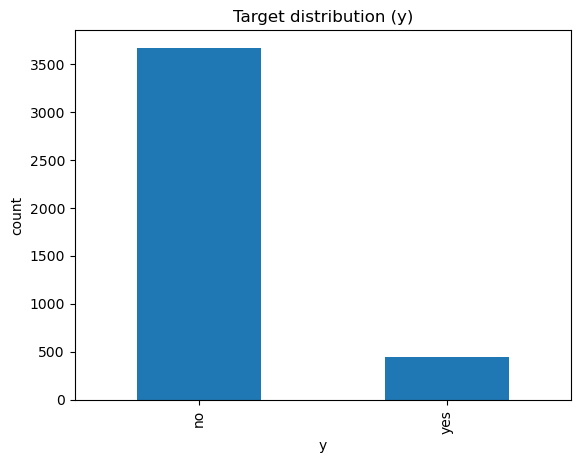

In [47]:
target_counts.plot(kind="bar")
plt.title("Target distribution (y)")
plt.xlabel("y")
plt.ylabel("count")
plt.show()

The bar plot visually reinforces the numerical findings by clearly showing the dominance of the “no” class over the “yes” class. The large disparity between bar heights confirms that the imbalance is not marginal but substantial.

Visual inspection helps communicate the magnitude of imbalance more intuitively than raw numbers alone. It makes evident that a model trained without special consideration may disproportionately favor the majority class.

The idxmax() function identifies the majority class, the class with the highest frequency. The maximum proportion (target_props.max()) represents the accuracy that would be achieved by a naïve classifier that always predicts this majority class.

This is known as the Zero Rule baseline. It serves as a reference point: any trained model should meaningfully outperform this baseline to demonstrate real predictive value.

In [48]:
# Zero Rule baseline (always predict the majority class)
majority_class = target_counts.idxmax()
zero_rule_accuracy = target_props.max()

print("Majority class:", majority_class)
print("Zero Rule baseline accuracy:", zero_rule_accuracy)

Majority class: no
Zero Rule baseline accuracy: 0.890507404709881


The Zero Rule baseline accuracy is approximately 89.05%, meaning that a naïve classifier that always predicts “no” would correctly classify nearly nine out of ten observations.

While this may initially appear to be strong performance, it is in fact misleading. Such a model would correctly classify almost all non-subscribers but would fail to identify most actual subscribers. Therefore, achieving high accuracy alone does not guarantee meaningful predictive performance in this context.

Overall, the target analysis confirms that class imbalance is a central structural characteristic of this dataset. The minority class (“yes”) is relatively rare, which increases the difficulty of correctly identifying potential subscribers. This observation directly informs subsequent methodological decisions: data splitting must be stratified to preserve class proportions, evaluation metrics must extend beyond accuracy to include precision and recall, and any resampling strategy must be applied exclusively to the training set to avoid data leakage. The imbalance is therefore not merely descriptive but has concrete implications for the design of the entire machine learning pipeline.

This class imbalance has several implications for the design of the machine learning pipeline:

Stratified Splitting: when dividing the dataset into training, validation, and test sets, stratification with respect to y will be necessary to preserve the original class proportions in each subset. Without stratification, the minority class could become underrepresented in one of the splits, leading to unstable training and unreliable evaluation.

Evaluation Metrics:
Accuracy measures the proportion of total predictions that are correct. However, in imbalanced datasets, accuracy can be misleading. In this case, since approximately 89% of clients do not subscribe, a classifier that always predicts “no” would already achieve about 89% accuracy, despite completely failing to identify most actual subscribers. Therefore, accuracy does not adequately reflect performance on the minority class.

Recall (for the “yes” class) measures the proportion of actual subscribers that the model correctly identifies. It answers the question: “Out of all clients who truly subscribed, how many did the model successfully detect?” High recall is important if the goal is to minimize missed opportunities (like failing to identify potential subscribers).

Precision (for the “yes” class) measures the proportion of predicted subscribers who are actually subscribers. It answers the question: “Out of all clients the model predicts will subscribe, how many truly do?” High precision is important when incorrect positive predictions are costly (like allocating marketing resources inefficiently).

In this business context, the minority class (“yes”) likely carries higher strategic value, as identifying potential subscribers is the primary objective of the campaign. Therefore, evaluating model performance solely through accuracy would obscure whether the model is effectively capturing the behavior of interest. Precision and recall provide a more meaningful assessment of performance on the minority class.

Resampling Strategy (Later Stage): The imbalance may motivate the use of resampling techniques (like oversampling or SMOTE) during model training. However, such techniques must be applied only to the training set, after data splitting, to avoid data leakage and artificially inflated performance.

In summary, the target distribution confirms that class imbalance is a central characteristic of this dataset. This observation directly informs subsequent steps in the pipeline, including stratified data splitting, metric selection, and potential training-set-only resampling.

#### Missing values

To ensure correct preprocessing, it is necessary to distinguish between explicit missing values (e.g., NaN) and implicit missing values (e.g., special categories such as "unknown" or sentinel codes).

In [49]:
# Check for explicit missing values (NaN)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

The function isna() detects explicit missing values represented as NaN. The results show that no variables contain explicit missing entries. Therefore, from a technical standpoint, the dataset does not require imputation of standard NaN values.

However, the absence of NaN values does not imply the absence of missing information. In many real-world datasets, missingness is encoded implicitly through special values or categories, which must be examined separately.

The dataset encodes missingness implicitly using the category "unknown" for several categorical variables. By counting occurrences of this value across columns, it is possible to quantify the extent of implicit missingness.

This type of missingness differs from NaN values because it is represented as a legitimate category. As a result, it requires a modeling decision: either treat "unknown" as its own category (assuming missingness may carry predictive information), or handle it through imputation or removal.

In [50]:
# Detect implicit missing values encoded as "unknown"
unknown_counts = (df == "unknown").sum().sort_values(ascending=False)
unknown_counts[unknown_counts > 0]

default      803
education    167
housing      105
loan         105
job           39
marital       11
dtype: int64

The analysis reveals the presence of implicit missing values encoded as "unknown" in several categorical variables. (803 for default, 167 for education, 105 for housing, 105 for loan, 39 for job, 11 for marital)

Given that the dataset contains 4,119 observations, the variable default has approximately 19.5% missing values encoded as "unknown", which is substantial.

Unlike explicit NaN values, these entries are stored as valid categorical levels. This means that missingness is structurally encoded rather than technically absent. As a result, a modeling decision must be made: either treat "unknown" as a legitimate category (assuming missingness may carry predictive information) or apply an imputation or recoding strategy.

Since these variables are categorical, treating "unknown" as its own category is often a reasonable approach, especially if the absence of information may itself correlate with client behavior.

It is also important to distinguish between “missing completely at random” and “informative missingness.” If clients with unknown default status systematically differ from others, then missingness itself may carry predictive signal. Therefore, removing or blindly imputing these values could discard useful information. 

However, this decision must later be implemented carefully within the training set only, to preserve pipeline discipline and avoid data leakage.

To assess the severity of implicit missingness, I computed the proportion of "unknown" entries per variable. This helps determine whether missingness is marginal or substantial.

Variables with a high proportion of "unknown" values may require special treatment, as large-scale missingness can influence model stability and interpretability.

In [51]:
# Percentage of "unknown" per column
unknown_percent = ((df == "unknown").sum() / len(df)).sort_values(ascending=False)
unknown_percent[unknown_percent > 0]

default      0.194950
education    0.040544
housing      0.025492
loan         0.025492
job          0.009468
marital      0.002671
dtype: float64

To evaluate the magnitude of implicit missingness, I computed the proportion of "unknown" values for each affected variable. 

The results show that: default contains approximately 19.5% unknown entries, education contains 4.05%, housing and loan each contain 2.55%, job contains 0.95%, and marital contains only 0.27%.

These results indicate that missingness is not uniformly distributed across variables. In particular, the variable default exhibits a substantial level of missingness, affecting nearly one-fifth of the dataset. In contrast, missingness in variables such as marital and job is minimal.

This heterogeneity suggests that different handling strategies may be appropriate for different variables. For example, dropping observations with "unknown" in default would remove nearly 20% of the dataset, which may reduce statistical power and introduce bias. Therefore, blindly dropping such observations would not be appropriate. Instead, treating "unknown" as its own category may preserve potentially informative patterns.

In variables with very low proportions of "unknown", the impact on model performance may be negligible, but consistency in the chosen missingness-handling strategy should be maintained across similar categorical variables.

Importantly, any decision regarding how to encode or transform missing values must later be implemented using only the training set, to prevent data leakage into validation or test sets.

Overall, the dataset contains no explicit missing values but exhibits structured implicit missingness through "unknown" categories. The magnitude and distribution of this missingness must be carefully considered when designing the preprocessing pipeline.

In addition to categorical implicit missingness encoded as "unknown", the dataset also contains a numerical sentinel value in the variable pdays. The value 999 appears in the majority of observations and represents a special condition, typically indicating that the client was not previously contacted, rather than a genuine number of days.

Although 999 is stored as a valid integer and does not appear as NaN, it does not represent a meaningful numerical distance. Treating it as an ordinary continuous value would mislead the model by implying a very large temporal gap rather than a structural absence of prior contact. Therefore, pdays contains implicit missingness encoded numerically and will require recoding (for example, creating an indicator variable for prior contact) before modeling.

This highlights the importance of distinguishing between technical missingness (NaN) and structurally encoded missingness (special categories or sentinel values). Both must be identified during exploratory analysis to ensure correct preprocessing.

#### Visualizing the distributions of variables

Visualization complements numerical summary statistics by revealing structural patterns that may not be immediately apparent from tables alone. 

Graphical analysis allows us to detect skewness, outliers, dominant categories, rare levels, and sentinel-coded values, all of which have direct implications for preprocessing decisions such as scaling, encoding, or recoding. 

The selected visualizations are used to test specific hypotheses about variable behavior and to identify potential modeling challenges before constructing the machine learning pipeline.

##### Numerical variables (2 at least)

Campaign hypothesis:

The summary statistics suggest that the variable `campaign` (number of contacts during the current campaign) may be strongly right-skewed, with a small number of clients contacted significantly more times than the typical client. 

This visualization will help us to confirm whether extreme values or outliers are present and to assess the degree of skewness. 

Detecting skewness is important because highly asymmetric distributions can influence coefficient estimation and stability in linear models such as Logistic Regression.

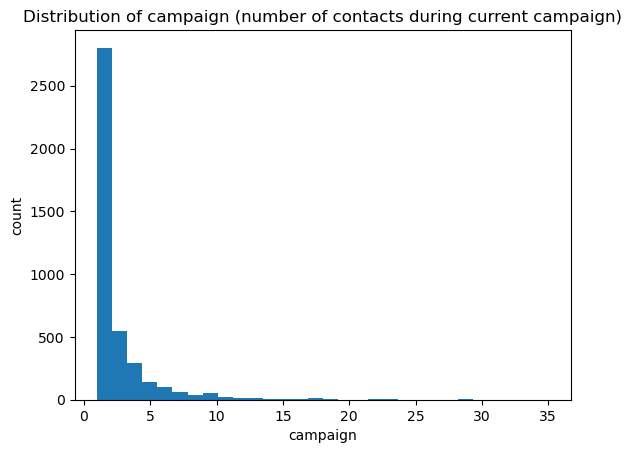

In [52]:
import matplotlib.pyplot as plt

df["campaign"].plot(kind="hist", bins=30)
plt.title("Distribution of campaign (number of contacts during current campaign)")
plt.xlabel("campaign")
plt.ylabel("count")
plt.show()

This histogram shows that `campaign` is strongly right-skewed: most clients were contacted a small number of times (typically between 1 and 3), while a really small minority were contacted many times (up to 35). 

This supports the hypothesis that `campaign` contains outliers/extreme values. In linear models such as Logistic Regression, highly skewed count variables can disproportionately influence coefficient estimation. Therefore, `campaign` may require careful preprocessing ( scaling, capping extreme values (winsorization), or transformation) in later stages.

pdays hypothesis:

Earlier summary statistics indicated that the variable `pdays` may contain a dominant sentinel value (999), which likely encodes “not previously contacted” rather than a true number of days. I visualize its distribution to confirm whether 999 overwhelmingly dominates the feature. If so, this would indicate that `pdays` does not behave as a standard continuous variable and may require recoding before modeling.

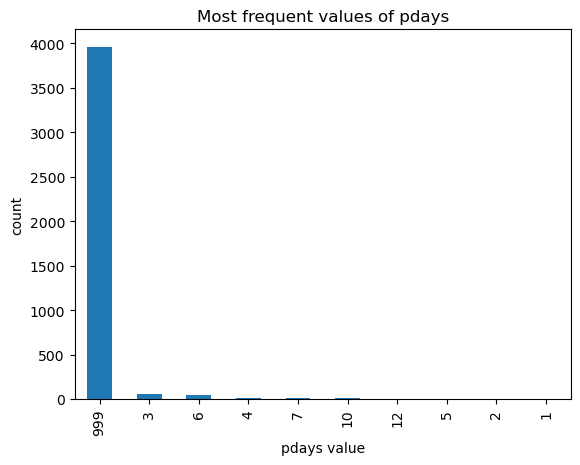

In [53]:
df["pdays"].value_counts().head(10).plot(kind="bar")
plt.title("Most frequent values of pdays")
plt.xlabel("pdays value")
plt.ylabel("count")
plt.show()

Instead of using a standard histogram, I plotted the most frequent values of `pdays` to directly test whether a sentinel value dominates the distribution. The plot confirms that 999 is overwhelmingly the most frequent value, consistent with the earlier summary statistics (median and upper quartiles equal to 999).

This suggests that `pdays` is not a standard continuous variable: the value 999 likely encodes a special condition (typically “client not previously contacted”) as we mentioned before. Treating 999 as a real number of days would misrepresent the feature and could mislead the model. This variable will therefore require recoding (like a binary indicator for prior contact, and possibly a cleaned numeric version for non-999 values) before modeling.

##### Categorical variables (2 at least)

For categorical variables, the key questions are: 
(1) how balanced are the categories
(2) whether there are rare categories that may cause sparse one-hot features 
(3) whether implicit missingness ("unknown") appears frequently.

job hypothesis:

The variable `job` contains multiple distinct categories, and I want to check whether their frequencies are unevenly distributed. 

Visualizing this variable will allow me to assess whether certain categories are rare, which could lead to sparse features after one-hot encoding. 

Identifying rare categories is important because they may reduce model stability or require grouping in later preprocessing steps.

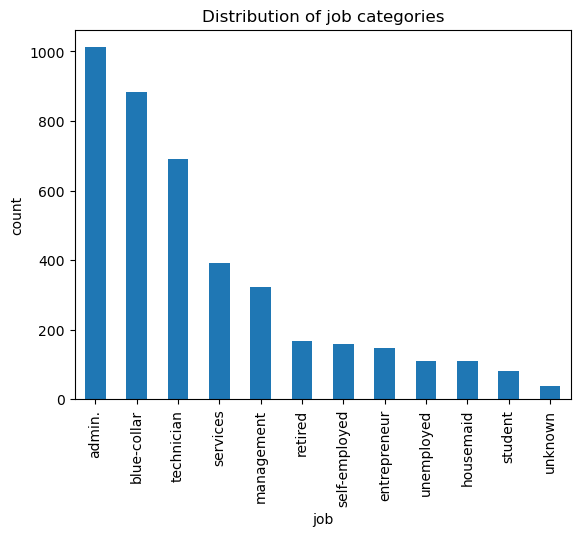

In [54]:
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of job categories")
plt.xlabel("job")
plt.ylabel("count")
plt.show()

The `job` variable has many distinct categories with uneven frequencies. This supports the hypothesis that one-hot encoding will create multiple binary features, and some categories may be relatively rare.

Rare categories can introduce sparsity and may reduce model robustness if the training set contains very few examples for a category. This observation motivates careful encoding (and potentially grouping very rare categories, if justified) in later preprocessing.

default hypothesis:

The missingness analysis revealed that the variable `default` contains a substantial proportion of `"unknown"` values (approximately 19.5%). 

I visualized this variable to confirm the magnitude of this category relative to the others. 

If `"unknown"` represents a large share of observations, this supports the interpretation that missingness is structurally encoded and may carry predictive information rather than being negligible noise.

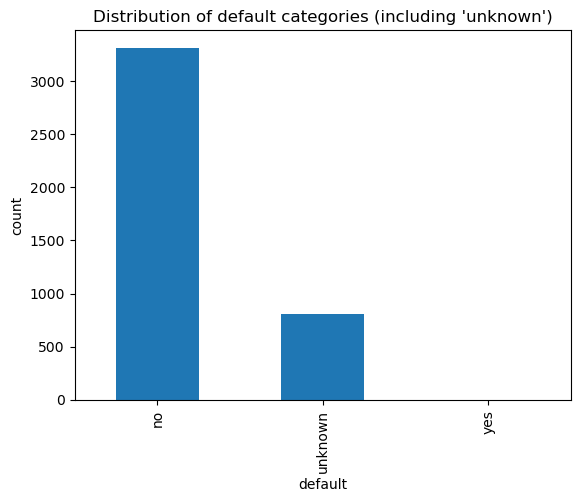

In [55]:
df["default"].value_counts().plot(kind="bar")
plt.title("Distribution of default categories (including 'unknown')")
plt.xlabel("default")
plt.ylabel("count")
plt.show()

The `default` variable includes a visibly large `"unknown"` category, confirming the implicit missingness analysis (approximately 19.5% of values are `"unknown"`). 

This supports the hypothesis that missingness is structurally encoded rather than represented as NaN. Dropping these rows would remove a large portion of the dataset and could introduce bias. A more reasonable modeling approach is to treat `"unknown"` as its own category during encoding, since missingness itself may carry predictive information.

#### Variables that need special considerations before modeling

Exploratory analysis reveald that several variables require special consideration before being used in a predictive model.

**1. `duration` -Call Duration**  
The variable `duration` represents the length of the phone call in seconds. While it may be highly predictive of subscription, it is only known after the call has taken place. Since the objective is to predict whether a client will subscribe using information available at the time of contact, including `duration` would introduce data leakage. It therefore requires special consideration and should be excluded from the predictive feature set.

**2. `pdays` -Days Since Last Contact**  
The distribution of `pdays` shows that the value 999 dominates the feature. This value likely represents a sentinel code meaning “client not previously contacted” rather than a true numerical measurement. Treating 999 as a standard continuous value would distort the feature’s meaning. Therefore, `pdays` may require recoding (like creating a binary indicator for prior contact and a cleaned numerical version for valid day counts).

**3. `campaign` -Number of Contacts During Current Campaign**  
The variable `campaign` exhibits strong right skew, with a small number of extreme values relative to the median. Highly skewed count variables can disproportionately influence coefficient estimation in Logistic Regression. As a result, `campaign` may require careful preprocessing, such as scaling, transformation, or potentially capping extreme values if justified or windsorization.

**4. `previous` -Number of Previous Contacts**  
The variable `previous` is strongly zero-inflated, with the majority of observations equal to zero. This suggests that the primary signal may be whether a client was previously contacted at all, rather than the exact number of prior contacts. Therefore, it may require recoding or special treatment to properly capture its predictive structure.

Overall, these variables illustrate different types of modeling challenges: information availability constraints (`duration`), sentinel-coded values (`pdays`), extreme skewness (`campaign`), and zero-inflated distributions (`previous`). Identifying such features during exploratory analysis ensures that appropriate preprocessing decisions can be made later in the pipeline.

## **Task 3: Data Partitioning (Training/ Validation/ Test)**

In this task, the dataset is split into training, validation, and test sets. This split is performed before any preprocessingto prevent data leakage and to ensure that model evaluation reflects true generalization.

### **Why we split the data**

To evaluate the model properly, we must simulate a real-world scenario where the model makes predictions on unseen clients. For this reason, the dataset is divided into three subsets:

- **Training set**: used to fit preprocessing steps (imputation, encoding, scaling) and train the model.
- **Validation set**: used to tune hyperparameters and compare model configurations during development.
- **Test set**: kept completely unseen until the end to provide an unbiased estimate of final model performance.

### **Justification of the 60–20–20 split**

A 60–20–20 split provides a balanced trade-off:

- 60% ensures sufficient data for the model to learn stable patterns.
- 20% validation data allows reliable hyperparameter tuning and model comparison.
- 20% test data ensures a robust and trustworthy final evaluation.

This distribution is appropriate given the dataset size and the need to maintain enough positive class examples in each subset. Theres no mathematical way to determine a priori which is the best way to spli the data, but we can use rules of thumb for it. 

### **Stratified splitting**

The target variable `y` (term deposit subscription) is class-imbalanced, meaning there are significantly fewer "yes" cases than "no" cases.

If the data were split randomly without stratification, some subsets might contain too few positive examples, leading to unstable evaluation metrics and misleading conclusions.

To prevent this, stratified splitting is applied. This ensures that each subset (training, validation, and test) preserves approximately the same proportion of "yes" and "no" values as the original dataset, resulting in more reliable training and evaluation. Training learns from a representative class balance, validation comparisons are fair and test performance is meaningful.

### **Where the split must happen in the ML pipeline (to avoid leakage)**

The split must occur before any preprocessing that learns from data, including:
imputing missing values (choosing medians/modes), encoding categoricals (learning category mappings), scaling/standardizing (learning mean/std), feature selection, outlier rules, PCA, etc.

If you preprocess before splitting, information from validation/test leaks into training. Examples of leakage:

-Scaling leakage: mean/std computed using all data makes the training data “aware” of the test distribution.
-Imputation leakage: using global medians/modes uses test-set information.
-Encoding leakage: category sets/frequencies learned from the full dataset can subtly advantage training and inflate performance.

This leads to over-optimistic results that won’t generalize.

**Preventing data leakage**

The dataset split is performed before any preprocessing or feature transformation to prevent data leakage. Data leakage occurs when the model has access to information that would not be available at prediction time, leading to inflated validation/test performance and overly optimistic results.

In this specific problem, the main types of leakage we are preventing are:

- **Preprocessing leakage**: If imputation, scaling, encoding, or feature selection were performed on the full dataset before splitting, the computed statistics (e.g., means, variances, category mappings) would incorporate information from the validation and test sets. This would expose the training process to the distribution of unseen data and artificially improve performance estimates.

- **Target leakage through feature selection or transformations**: If correlations with the target variable `y` were computed using the entire dataset before splitting, information about the validation and test labels would indirectly influence the training process. Any transformation that depends on the target must be learned exclusively on the training set.

By splitting the raw data first and fitting all preprocessing steps only on the training set, we ensure that the validation and test sets remain truly unseen. This preserves the independence between splits and guarantees a reliable estimate of real-world model performance.

### **Implementation of the two-step stratified split**

Following best practice, the dataset is first split into a training set (60%) and a temporary set (40%). The temporary set is then split equally into validation (20%) and test (20%) sets. Stratification is applied in both steps to preserve the class distribution.

**Excluding `duration` before splitting**

Before separating features from the target, the variable `duration` is explicitly removed from the feature set.

Although `duration` (call duration in seconds) is strongly correlated with the subscription outcome, it is only known after the call has already taken place. Since the objective of this model is to predict whether a client will subscribe **at the time of contact**, `duration` would not be available as an input feature in any real deployment scenario.

Including `duration` would therefore constitute **target leakage**: the model would learn from information that is unavailable at prediction time, producing artificially inflated performance estimates that would not generalise to real-world use. For this reason, `duration` is excluded from `X` before splitting, ensuring it plays no role in any stage of the pipeline.

In [56]:
from sklearn.model_selection import train_test_split

# duration is excluded here because it is only known after the call ends.
# Including it would constitute target leakage: the model would be trained
# on information that is unavailable at actual prediction time.
X = df.drop(columns=["y", "duration"])
y = df["y"]

# Step 1: Split into Train (60%) and Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

# Step 2: Split Temp into Validation (20%) and Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape, " Target:", y_train.shape)
print("Val size:  ", X_val.shape,   " Target:", y_val.shape)
print("Test size: ", X_test.shape,  " Target:", y_test.shape)

print("\nClass proportions (y='yes'):")
print("Full: ", (y == "yes").mean())
print("Train:", (y_train == "yes").mean())
print("Val:  ", (y_val == "yes").mean())
print("Test: ", (y_test == "yes").mean())

Train size: (2471, 19)  Target: (2471,)
Val size:   (824, 19)  Target: (824,)
Test size:  (824, 19)  Target: (824,)

Class proportions (y='yes'):
Full:  0.10949259529011895
Train: 0.10967219749089438
Val:   0.10922330097087378
Test:  0.10922330097087378


## Task 4: Managing Missing Values

All missing value transformations (e.g., recoding `pdays`) are applied after splitting and defined using the training data. Validation and test sets are transformed using the same deterministic rules. This ensures that no information from validation or test influences the training process, maintaining proper pipeline discipline and preventing data leakage.

### identify explicit and implicit missing values

This step addresses missing-value handling after the dataset has been split into training, validation, and test sets. Missing-value management is considered a preprocessing operation that may influence the representation of the data; therefore, it must occur after splitting to prevent data leakage. Any transformation or recoding decision must be defined using the training set and then applied consistently to validation and test sets.

In this dataset, two types of missingness must be distinguished:

1. **Explicit missingness (NaN values):**  
   These are technically absent entries represented as `NaN` in pandas. Explicit missing values require standard imputation strategies (e.g., mean, median, or mode). However, this dataset does not contain any NaN values, as we saw in the exploratory data analysis.

2. **Implicit missingness:**  
   Missing information encoded as legitimate values rather than NaN. In this dataset, implicit missingness appears in two forms:
   
   - **Categorical implicit missingness:**  
     Placeholder categories such as `"unknown"` represent unobserved or unavailable information. Although stored as valid string categories, they indicate incomplete data.
   
   - **Numerical sentinel missingness:**  
     Special numerical codes (ex. `pdays = 999`) represent structural conditions rather than true numeric measurements. In this case, 999 encodes “client not previously contacted” rather than a genuine number of days, as we previously analyzed during data exploration.

Because implicit missingness may carry predictive signal and is structurally encoded rather than randomly absent, handling decisions must preserve information while avoiding distortion of feature meaning.

In [57]:
# Sanity check: explicit missing values (NaN) in each split
print("NaN counts (train):", X_train.isna().sum().sum())
print("NaN counts (val):  ", X_val.isna().sum().sum())
print("NaN counts (test): ", X_test.isna().sum().sum())

NaN counts (train): 0
NaN counts (val):   0
NaN counts (test):  0


We can confinrm again that there is no explicit missingness in any split. Therefore, standard imputation methods (mean/median/mode) are not required for this dataset in particular.

In [58]:
# Count "unknown" values per column in each split
unknown_train = (X_train == "unknown").sum().sort_values(ascending=False)
unknown_val   = (X_val == "unknown").sum().sort_values(ascending=False)
unknown_test  = (X_test == "unknown").sum().sort_values(ascending=False)

print("Unknown counts (train):")
print(unknown_train[unknown_train > 0])

print("\nUnknown counts (val):")
print(unknown_val[unknown_val > 0])

print("\nUnknown counts (test):")
print(unknown_test[unknown_test > 0])

Unknown counts (train):
default      492
education    104
housing       55
loan          55
job           20
marital        7
dtype: int64

Unknown counts (val):
default      169
education     30
housing       27
loan          27
job            8
marital        1
dtype: int64

Unknown counts (test):
default      142
education     33
housing       23
loan          23
job           11
marital        3
dtype: int64


### Quantifying the extent of missingness for each affected variable

In [59]:
# Compute proportion of "unknown" per column in each split

unknown_prop_train = ((X_train == "unknown").sum() / len(X_train)).sort_values(ascending=False)
unknown_prop_val   = ((X_val == "unknown").sum() / len(X_val)).sort_values(ascending=False)
unknown_prop_test  = ((X_test == "unknown").sum() / len(X_test)).sort_values(ascending=False)

print("Unknown proportions (train):")
print(unknown_prop_train[unknown_prop_train > 0])

print("\nUnknown proportions (val):")
print(unknown_prop_val[unknown_prop_val > 0])

print("\nUnknown proportions (test):")
print(unknown_prop_test[unknown_prop_test > 0])

Unknown proportions (train):
default      0.199110
education    0.042088
housing      0.022258
loan         0.022258
job          0.008094
marital      0.002833
dtype: float64

Unknown proportions (val):
default      0.205097
education    0.036408
housing      0.032767
loan         0.032767
job          0.009709
marital      0.001214
dtype: float64

Unknown proportions (test):
default      0.172330
education    0.040049
housing      0.027913
loan         0.027913
job          0.013350
marital      0.003641
dtype: float64


The proportions confirm that implicit categorical missingness is present across all splits and remains broadly consistent due to stratified splitting.

In the training set, the variable `default` exhibits the highest proportion of missingness (approximately 19.9%), followed by `education` (~4.2%). Smaller proportions are observed in `housing` and `loan` (~2.2%), `job` (~0.8%), and `marital` (~0.3%).

The validation and test sets show very similar proportions. In validation, `default` is approximately 20.5%, while in the test set it is approximately 17.2%. The proportions for `education`, `housing`, `loan`, `job`, and `marital` remain close to those observed in the training set, with only minor sampling variation.

This consistency confirms that stratified splitting preserved the structural distribution of implicit missingness across subsets. As a result, the missing-value handling strategy defined using the training data remains appropriate and stable for validation and test evaluation.

### Strategies for handling missing values

The results confirm that implicit missingness is present as `"unknown"` categories (particularly in `default`, and to a lesser extent in `education`, `housing`, `loan`, `job`, and `marital`). Because these are structurally encoded categories rather than NaN values—and may carry predictive signal—the strategy is to keep `"unknown"` as a valid category and handle it naturally during categorical encoding in later steps.

Numerical sentinel missingness: `pdays = 999`
The variable `pdays` contains the value 999, which represents “client not previously contacted” rather than a true number of days as we analyzed at the data exploration stage. Before transforming it, I will verify how dominant this sentinel value is in the training set.

In [60]:
print("Top values of pdays (train):")
print(X_train["pdays"].value_counts().head())

Top values of pdays (train):
pdays
999    2368
3        34
6        27
4        11
7         6
Name: count, dtype: int64


To avoid misleading the model, I recode `pdays` into two features:

- `previously_contacted`: a binary indicator equal to 1 if the client was previously contacted (pdays ≠ 999), and 0 otherwise.
- `pdays_clean`: the original day count for previously contacted clients, with the sentinel value 999 replaced by 0 (since the indicator already captures the distinction).

This preserves the structural meaning of the variable while preventing the model from interpreting 999 as an actual numeric distance.

In [61]:
def recode_pdays(df_in):
    df_out = df_in.copy()
    df_out["previously_contacted"] = (df_out["pdays"] != 999).astype(int)
    df_out["pdays_clean"] = df_out["pdays"].replace(999, 0)
    df_out = df_out.drop(columns=["pdays"])
    return df_out

X_train_mv = recode_pdays(X_train)
X_val_mv   = recode_pdays(X_val)
X_test_mv  = recode_pdays(X_test)

In [62]:
print("pdays in X_train_mv?", "pdays" in X_train_mv.columns)
print("New columns present?",
      {"previously_contacted", "pdays_clean"}.issubset(X_train_mv.columns))

print("\npreviously_contacted distribution (train):")
print(X_train_mv["previously_contacted"].value_counts())

print("\npdays_clean summary (train):")
print(X_train_mv["pdays_clean"].describe())

pdays in X_train_mv? False
New columns present? True

previously_contacted distribution (train):
previously_contacted
0    2368
1     103
Name: count, dtype: int64

pdays_clean summary (train):
count    2471.000000
mean        0.240389
std         1.407500
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        19.000000
Name: pdays_clean, dtype: float64


After recoding, the original `pdays` column has been removed and replaced with a binary indicator (`previously_contacted`) and a cleaned numerical feature (`pdays_clean`). 

This approach preserves the structural meaning of the original variable, avoids distorting the feature space, and ensures that missingness encoded via sentinel values is handled appropriately without introducing data leakage.

It is important to distinguish between **data cleaning decisions** and **modeling decisions**:

- Data cleaning would involve correcting errors or removing corrupted entries.
- In this dataset, missingness is structurally encoded rather than erroneous. Therefore, handling it is a modeling decision.

So in conclusion the adopted strategies are:

- For categorical `"unknown"` values:  
  These are retained as valid categories. Removing rows would discard a significant portion of the dataset (especially for `default`), and imputing the most frequent category would introduce artificial certainty. Treating `"unknown"` as its own category preserves potentially informative missingness.

- For `pdays = 999`:  
  The variable is recoded into:
  - `previously_contacted` (binary indicator), and  
  - `pdays_clean` (numeric day count with sentinel replaced by 0).  
  This preserves structural meaning while preventing distortion from treating 999 as a real numeric value.

### Training-Only Fitting and the Distinction Between Cleaning and Modeling Decisions

It is important to distinguish between **data cleaning decisions** and **modeling decisions** in the context of missing values.

Data cleaning refers to correcting errors or inconsistencies in the dataset (e.g., fixing corrupted entries or removing invalid records). In this dataset, the missingness observed is not due to corrupted data but is structurally encoded through `"unknown"` categories and the sentinel value `pdays = 999`. Therefore, the handling of missingness is a **modeling decision**, not a cleaning operation.

Any preprocessing step that estimates parameters from the data must be fitted using the training set only. In general, this includes operations such as:
- imputing missing values using means, medians, or modes,
- determining category mappings during encoding,
- computing scaling statistics (mean and standard deviation),
- selecting features based on variance or correlation thresholds,
- generating synthetic samples through resampling techniques.

Fitting such operations on the full dataset would allow information from the validation or test sets to influence the training process, resulting in data leakage and overly optimistic evaluation metrics. 

In this specific missing-value strategy:
- Retaining `"unknown"` as a category does not require estimating parameters from validation or test data.
- Recoding `pdays = 999` into a deterministic indicator (`previously_contacted`) and a cleaned numeric feature (`pdays_clean`) does not rely on learned statistics.

Nevertheless, these transformations are defined within the training-based pipeline and then applied consistently to validation and test sets to preserve strict separation between model development and evaluation.

## Task 5: Encoding categorical variables

Logistic Regression requires numerical input features. Since this dataset contains multiple categorical variables (like `job`, `marital`, `contact`), these variables must be encoded into a numeric representation before modeling.

This step must be performed after train/validation/test splitting. Encoders learn information from the data (like the set of observed categories and the mapping to output columns). Therefore, the encoder must be fitted on the training set only, and then the same fitted transformation must be applied unchanged to validation and test sets to prevent data leakage.

### Identify categorical variables in the dataset

In [63]:
# Identify categorical vs numerical features AFTER missing-value handling
categorical_features = X_train_mv.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train_mv.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical features: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'pdays_clean']


### Nominal variables vs ordinal variables

Categorical variables can be divided into two types: **nominal** and **ordinal**.

- **Nominal variables** represent categories with no intrinsic order. The categories are distinct labels, and no ranking or numerical relationship exists between them (e.g., job types). Assigning numerical codes to nominal variables would impose an artificial ordering that does not reflect reality and could mislead a linear model.

- **Ordinal variables** represent categories with a meaningful and consistent order (e.g., increasing levels of education). In these cases, the relative ranking carries information, and preserving this structure may benefit a linear model if the ordering is correct.

In this dataset, the categorical variables are classified as follows:

#### Ordinal Variable

- `education`  
  Education levels follow a natural progression (e.g., basic education → high school → university degree). The ordering reflects increasing educational attainment, which may correlate with financial behavior and subscription likelihood. Therefore, `education` is treated as an ordinal variable with an explicitly defined order.  
  It is important to specify the ordering manually to avoid arbitrary alphabetical ordering imposed by default encoders.

#### Nominal Variables

The following variables are treated as nominal because their categories do not have a meaningful numerical ranking:

- `job` – Different professions (e.g., technician, management, blue-collar) have no inherent numeric order.
- `marital` – Categories such as single, married, divorced are labels, not ranked states.
- `default` – Indicates whether a client has credit in default; although binary in structure, it is categorical and not ordinal in the sense of graded levels.
- `housing` – Indicates presence of a housing loan (yes/no/unknown); there is no graded ordering.
- `loan` – Indicates presence of a personal loan; again categorical without ranking.
- `contact` – Type of communication (cellular/telephone); unordered categories.
- `month` – Month of contact; although months follow a calendar sequence, in this context they represent seasonal categories rather than a meaningful numeric progression for linear modeling.
- `day_of_week` – Similar to month; represents categorical scheduling information.
- `poutcome` – Outcome of previous campaign (success/failure/nonexistent); these are distinct categories without numeric ranking.

These variables are therefore encoded using **One-Hot Encoding**, which creates separate binary indicators for each category and avoids imposing artificial linear structure.

### Justification in the Context of Logistic Regression

Logistic Regression is a linear model that assumes a linear relationship between features and the log-odds of the outcome. If nominal variables were encoded as integers (e.g., job=1, job=2, job=3), the model would incorrectly interpret the numbers as ordered and equidistant, introducing unintended structure into the decision boundary.

One-Hot Encoding avoids this issue by representing each category independently. For ordinal variables such as `education`, encoding with a defined order preserves meaningful structure without artificially inflating dimensionality.

Thus, the encoding strategy aligns with both the semantic meaning of each variable and the mathematical assumptions of Logistic Regression.

### Select & Apply encoding strategy for each categorical variable

Based on the classification above, I apply two encoding strategies:

- **Ordinal Encoding for `education`** using an explicitly defined order. This preserves educational attainment as a single ordered feature. Because Logistic Regression is linear in the feature space, ordinal encoding implies a monotonic relationship: moving from a lower to a higher education level corresponds to a consistent directional change in the log-odds, captured by a single coefficient.

- **One-Hot Encoding for all nominal categorical variables**. This avoids imposing artificial order and allows the model to learn category-specific effects. Each category receives its own coefficient, enabling Logistic Regression to represent different shifts in log-odds for different categories.

To maintain pipeline discipline, all encoders are fitted only on the training set and then applied unchanged to validation and test sets.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Ordinal order for education (increasing educational attainment)
education_order = [
    "unknown",
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree"
]

ordinal_features = ["education"] if "education" in categorical_features else []
nominal_features = [c for c in categorical_features if c not in ordinal_features]

# ColumnTransformer applies ordinal encoding to education,
# one-hot encoding to all other nominal categorical variables,
# and passes numerical variables through unchanged for scaling in Task 6.
encoder = ColumnTransformer(
    transformers=[
        ("edu_ord", OrdinalEncoder(categories=[education_order]), ordinal_features),
        ("cat_ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal_features),
        ("num_pass", "passthrough", numerical_features)
    ],
    remainder="drop"
)

# Fit ONLY on training data (prevents leakage)
encoder.fit(X_train_mv)

# Transform all splits using the fitted encoder
X_train_enc = encoder.transform(X_train_mv)
X_val_enc   = encoder.transform(X_val_mv)
X_test_enc  = encoder.transform(X_test_mv)

print("Encoded shapes:")
print("X_train_enc:", X_train_enc.shape)
print("X_val_enc:  ", X_val_enc.shape)
print("X_test_enc: ", X_test_enc.shape)

Encoded shapes:
X_train_enc: (2471, 56)
X_val_enc:   (824, 56)
X_test_enc:  (824, 56)


The encoded feature matrices have 57 columns, compared to a smaller number of features before encoding. This confirms that One-Hot Encoding expanded the dimensionality of the dataset by creating separate binary indicators for each nominal category. 

The number of rows remains unchanged across splits, indicating that encoding transformed the feature representation without altering the sample size. The identical number of columns across training, validation, and test sets confirms that the encoder was fitted on the training set and consistently applied to the other splits.

Training-only fitting: which encoders must be fitted on training data and why?

Both **OrdinalEncoder** and **OneHotEncoder** must be fitted using the training set only, because fitting an encoder is not just a formatting step, it extracts information from the data:

- The **OneHotEncoder** learns the set of categories observed during fitting and the resulting mapping from categories to output columns. If it were fitted on the full dataset, the training process would indirectly benefit from information about categories that appear only in validation or test.

- The **OrdinalEncoder** learns how categories map to numeric codes. Even when a manual ordering is specified, fitting still establishes the final mapping used by the pipeline.

Fitting encoders on the full dataset would lead to data leakage, because it allows the training pipeline to “peek” at the evaluation sets. Therefore, the correct procedure is to fit encoders on training only and then transform validation and test sets with the fitted encoders.

### How encoding affects dimensionality, interpretability & decision boundaries

#### 1) Dimensionality of the dataset

Encoding changes the representation of the feature space. One-hot encoding expands the dataset by replacing each nominal variable with multiple binary indicator columns—one per category. As a result, the total number of input features increases substantially compared to the original dataset. This increase is expected and is the cost of representing categorical information without imposing a false ordering.

In contrast, ordinal encoding keeps a single column for `education`, so it does not increase dimensionality. However, it embeds a strong assumption: adjacent education categories are treated as equally spaced steps along one dimension.

#### 2) Interpretability of Logistic Regression coefficients

In Logistic Regression, each coefficient corresponds to the change in log-odds associated with a one-unit increase in the feature (holding other features constant).

- With **one-hot encoding**, each coefficient represents the effect of belonging to a specific category relative to the baseline case (when all indicators for that variable are zero, depending on how categories are represented). This makes coefficients interpretable as category-specific shifts in log-odds. For example, a positive coefficient for `job=student` means that being a student is associated with higher log-odds of subscribing compared to the reference behavior captured by the remaining features.

- With **ordinal encoding** (`education`), the single coefficient represents the effect of increasing education by one level in the specified ordering. This implies a monotonic linear relationship between education level and log-odds, which is only appropriate if the ordering is meaningful and the relationship is approximately monotonic.

Thus, encoding directly determines whether coefficients capture category-specific effects (one-hot) or a single ordered trend (ordinal).

#### 3) Decision boundaries and expressiveness of a linear model

Logistic Regression learns a linear decision boundary in the encoded feature space. Encoding determines what “linear” means in practice:

- With **one-hot encoding**, the model can assign different weights to different categories independently. This allows the decision boundary to represent distinct shifts for each category (e.g., different intercept-like adjustments per job type). Importantly, the model does not assume any numeric relationship between categories—each category is treated as a separate direction in feature space.

- With **ordinal encoding**, the model is constrained to treat higher education levels as systematically “more” of the same feature. This restriction can be beneficial if the true relationship is monotonic, but it reduces expressiveness if the effect is non-monotonic (e.g., if middle education levels behave differently from both low and high levels).

Therefore, encoding is not a mechanical step: it determines the geometry of the feature space and directly affects what patterns a linear classifier can represent and how reliably its coefficients reflect meaningful relationships.

In [65]:
# Quantify dimensionality change
print("Original number of features (after missing-value handling):", X_train_mv.shape[1])
print("Number of features after encoding:", X_train_enc.shape[1])
print("Increase in dimensionality:", X_train_enc.shape[1] - X_train_mv.shape[1])

# Build full feature name list for interpretability
ohe = encoder.named_transformers_["cat_ohe"]
ohe_feature_names = ohe.get_feature_names_out(nominal_features).tolist() if nominal_features else []

final_feature_names = (
    ordinal_features
    + ohe_feature_names
    + numerical_features
)

print("\nFirst 25 feature names:")
print(final_feature_names[:25])

Original number of features (after missing-value handling): 20
Number of features after encoding: 56
Increase in dimensionality: 36

First 25 feature names:
['education', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'marital_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown']


The dimensionality increased from 21 to 57 features after encoding, reflecting the expansion introduced by One-Hot Encoding. Each nominal categorical variable was decomposed into multiple binary indicator columns, one per category. 

This confirms that categorical variables are now represented independently rather than as artificially ordered integers. The preserved `education` column (ordinal encoding) remains a single feature, while nominal variables such as `job`, `marital`, and `default` expanded into multiple columns.

The increase in dimensionality enhances the expressive capacity of the linear model, allowing category-specific effects to be learned. However, it also increases the number of parameters, reinforcing the importance of regularization in Logistic Regression.

All categorical variables were encoded to make them suitable for Logistic Regression. Nominal variables were one-hot encoded to avoid introducing artificial ordering and to enable category-specific coefficients. The variable `education` was ordinal-encoded using an explicitly defined, semantically meaningful ordering. Both encoders were fitted only on the training set and then applied to validation and test sets to preserve pipeline discipline and prevent data leakage. Encoding significantly increases feature dimensionality and shapes both coefficient interpretability and the expressiveness of the linear decision boundary.

## Task 6: Feature scaling 

Feature scaling is a critical preprocessing step for linear models such as Logistic Regression. Although scaling does not change the underlying relationships between variables and the target, it significantly affects the optimization process and the interpretability of model coefficients.

Logistic Regression is typically trained using gradient-based optimization methods. When numerical features operate on very different scales (e.g., `euribor3m` ranging between 0–5 versus `nr.employed` in the thousands), features with larger magnitudes can dominate the gradient updates. This can slow convergence, destabilize optimization, and implicitly bias the model toward variables with larger numeric ranges.

Therefore, numerical variables should be scaled to comparable magnitudes before training. As with all preprocessing steps that learn parameters from the data the scaler must be fitted only on the training set and then applied unchanged to validation and test sets to prevent data leakage.

### Numerical variables that require scaling

After missing-value handling, numerical variables are identified programmatically using their pandas data types (`int64` or `float64`). However, not all numerical variables necessarily require scaling.

In this pipeline, scaling is applied to numerical variables whose magnitudes vary widely (continuous and count-based features), since these differences affect Logistic Regression optimization and coefficient comparability. Binary indicator variables (values in {0,1}) already lie on a common bounded scale and typically do not require scaling.

The code below identifies all numerical variables, and separates them into variables that require scaling versus binary indicators.

In [66]:
import numpy as np

# After encoding, identify the positions of numerical features in the encoded matrix.
# We retrieve the feature names from the encoder to locate which columns are numerical.
ohe = encoder.named_transformers_["cat_ohe"]
ohe_feature_names = ohe.get_feature_names_out(nominal_features).tolist()

# Full ordered list of feature names after encoding
encoded_feature_names = ordinal_features + ohe_feature_names + numerical_features

# Identify which of the numerical features are binary (0/1) vs continuous
binary_numeric_vars = []
scale_numeric_vars = []

for col in numerical_features:
    unique_vals = set(X_train_mv[col].dropna().unique())
    if unique_vals.issubset({0, 1}):
        binary_numeric_vars.append(col)
    else:
        scale_numeric_vars.append(col)

print("Binary variables (no scaling needed):", binary_numeric_vars)
print("\nContinuous variables to scale:", scale_numeric_vars)

Binary variables (no scaling needed): ['previously_contacted']

Continuous variables to scale: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'pdays_clean']


The output confirms that the dataset contains the following numerical variables after missing-value handling:

`age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`, `previously_contacted`, and `pdays_clean`.

Among these, `previously_contacted` is a binary indicator taking values in {0,1} and therefore does not require scaling, since it already operates within a consistent bounded range, it functions as a binary indicator rather than a continuous feature. Binary features already operate on a consistent bounded scale and do not distort gradient magnitudes.

The remaining numerical variables — `age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`, and `pdays_clean` — operate on substantially different magnitudes. For example, `euribor3m` ranges approximately between 0 and 5, whereas `nr.employed` is measured in the thousands. 

Note that `duration` was excluded from the pipeline at the splitting stage, as it is only known after the call ends and would constitute target leakage.

Such scale differences can influence gradient-based optimization in Logistic Regression, since features with larger numeric ranges can dominate gradient updates and implicitly affect coefficient magnitudes. Therefore, these continuous and count-based variables are selected for scaling.

### Selecting and justifying the scaling strategy

To scale the selected numerical variables, I use **standardization** (z-score scaling) via `StandardScaler`. Standardization transforms each feature \(x\) into:

\[
z = \frac{x - \mu}{\sigma}
\]

where \(\mu\) and \(\sigma\) are the mean and standard deviation estimated from the training set.

Standardization is preferred over normalization (e.g., MinMax scaling) for several reasons in the context of Logistic Regression:

1. **Optimization Stability**  
   Logistic Regression is trained using gradient-based optimization. When features have very different magnitudes, gradients associated with large-scale variables can dominate updates, slowing convergence or destabilizing optimization. Standardization centers variables around zero and scales them to unit variance, improving numerical conditioning and convergence behavior.

2. **Regularization Fairness**  
   Logistic Regression commonly uses L1 or L2 regularization. Regularization penalizes large coefficients. If features are not standardized, variables with larger natural scales may receive smaller coefficients simply because their values are large, while small-scale variables may receive disproportionately large coefficients. Standardization ensures that the regularization penalty is applied comparably across features.

3. **Interpretability of Coefficients**  
   After standardization, each coefficient represents the effect of a one-standard-deviation increase in the feature on the log-odds of the outcome. This makes coefficients more comparable across variables.

4. **Why not MinMax Scaling?**  
   MinMax scaling rescales variables to a fixed interval (e.g., [0,1]). While this also reduces scale differences, it does not center features around zero and is more sensitive to extreme values. Since Logistic Regression models linear relationships in log-odds space and often benefits from zero-centered features for optimization efficiency, standardization is more appropriate here.

As with all transformations that estimate parameters from the data, the scaler is fitted exclusively on the training set and then applied unchanged to validation and test sets to prevent data leakage.

In [67]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Convert encoded arrays to DataFrames with correct column names
X_train_enc_df = pd.DataFrame(X_train_enc, columns=encoded_feature_names)
X_val_enc_df   = pd.DataFrame(X_val_enc,   columns=encoded_feature_names)
X_test_enc_df  = pd.DataFrame(X_test_enc,  columns=encoded_feature_names)

# Force numeric columns to correct dtype explicitly
for col in scale_numeric_vars + binary_numeric_vars:
    X_train_enc_df[col] = pd.to_numeric(X_train_enc_df[col])
    X_val_enc_df[col]   = pd.to_numeric(X_val_enc_df[col])
    X_test_enc_df[col]  = pd.to_numeric(X_test_enc_df[col])

# Fit scaler ONLY on training data (prevents leakage)
scaler = StandardScaler()
scaler.fit(X_train_enc_df[scale_numeric_vars])

# Apply scaling to continuous numerical columns only
X_train_processed = X_train_enc_df.copy()
X_val_processed   = X_val_enc_df.copy()
X_test_processed  = X_test_enc_df.copy()

X_train_processed[scale_numeric_vars] = scaler.transform(X_train_enc_df[scale_numeric_vars])
X_val_processed[scale_numeric_vars]   = scaler.transform(X_val_enc_df[scale_numeric_vars])
X_test_processed[scale_numeric_vars]  = scaler.transform(X_test_enc_df[scale_numeric_vars])

# Sanity check: means ~0 and stds ~1
print("Train means (approx 0):")
print(X_train_processed[scale_numeric_vars].mean().round(3))
print("\nTrain stds (approx 1):")
print(X_train_processed[scale_numeric_vars].std(ddof=0).round(3))

Train means (approx 0):
age              -0.0
campaign         -0.0
previous         -0.0
emp.var.rate      0.0
cons.price.idx   -0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
pdays_clean       0.0
dtype: float64

Train stds (approx 1):
age               1.0
campaign          1.0
previous          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
pdays_clean       1.0
dtype: float64


The output confirms the numerical variables present after encoding. Among these, `previously_contacted` is a binary indicator (values in {0,1}) and does not require scaling. 

The remaining continuous variables — `age`, `campaign`, `previous`, `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`, and `pdays_clean` — operate on substantially different magnitudes and are selected for standardisation. Note that `duration` has been excluded from the pipeline entirely, as it is only known after the call ends and would constitute target leakage.

The output confirms that all selected numerical variables have been successfully standardized:

- The mean of each scaled feature in the training set is approximately 0.
- The standard deviation of each scaled feature is approximately 1.

This verifies that standardization was correctly applied using statistics computed from the training set only. Minor values such as “-0.0” are due to floating-point precision and are effectively zero.

Standardizing the training set in this way ensures that all continuous and count-based numerical features operate on comparable magnitudes before model training.

To summarise, standardization is chosen because Logistic Regression is a linear model trained using gradient-based optimization and often regularized with L1 or L2 penalties. When features operate on different scales, large-magnitude variables can dominate gradient updates and distort coefficient magnitudes. By centering features at zero and scaling them to unit variance, standardization improves numerical stability, ensures fair regularization across coefficients, and makes parameter magnitudes directly comparable. Unlike MinMax scaling, standardization is less sensitive to extreme values and better aligned with the mathematical behavior of linear models.

### Training-Only Fitting and Data Leakage Prevention
The `StandardScaler` must be fitted exclusively on the training set because it estimates parameters from the data—specifically the mean and standard deviation of each feature. If these statistics were computed using the full dataset before splitting, information from the validation and test sets would influence the training process, resulting in data leakage.

By fitting the scaler only on the training data and then applying the learned transformation unchanged to validation and test sets, we ensure that model development remains strictly separated from evaluation. This preserves the integrity of performance estimates and guarantees that validation and test sets simulate truly unseen data.

### Theoretical implications of feature scaling in Logistic Regression

Feature scaling is not a cosmetic transformation; it directly affects the mathematical behavior of linear models such as Logistic Regression.

#### Gradient-based optimization: 

Logistic Regression is typically trained by minimizing a loss function (e.g., cross-entropy) using gradient-based optimization methods. The gradient of the loss with respect to each coefficient depends on the magnitude of its corresponding feature.

If features operate on very different scales, the gradients associated with large-scale variables (e.g., `nr.employed`, measured in thousands) can dominate updates compared to small-scale variables (e.g., `euribor3m`). This results in an ill-conditioned optimization problem, where the loss surface becomes elongated in some directions and compressed in others. Consequently, convergence may be slower, unstable, or highly sensitive to the learning rate.

By standardizing features to zero mean and unit variance, the optimization landscape becomes better conditioned. Gradients are balanced across dimensions, leading to more stable and efficient convergence.

#### The magnitud and comparability of model coefficients

In Logistic Regression, each coefficient represents the change in log-odds associated with a one-unit increase in the corresponding feature. Without scaling, a one-unit increase does not have comparable meaning across variables (e.g., one second of call duration vs one unit in a macroeconomic index).

After standardization, a one-unit increase corresponds to a one-standard-deviation change in the feature. This makes coefficients directly comparable across variables: differences in coefficient magnitude reflect relative predictive influence rather than arbitrary measurement units.

Thus, scaling improves interpretability and prevents misleading comparisons of coefficient sizes.

#### The interpretation of regularization penalities

When regularization (L1 or L2) is applied, the penalty term depends on the magnitude of the coefficients. If features are not scaled, variables with naturally large numeric ranges can achieve strong predictive effects with smaller coefficients, incurring smaller penalties. Conversely, small-scale variables may require larger coefficients to produce comparable effects and therefore be penalized more heavily.

This introduces an unintended bias in how regularization shrinks coefficients.

Standardization ensures that all numerical variables contribute on comparable scales, making the regularization penalty operate fairly across features. As a result, coefficient shrinkage reflects true predictive importance rather than differences in measurement units.

In summary, feature scaling directly influences optimization stability, coefficient interpretation, and the behavior of regularization in linear models. It is therefore a mathematically necessary step rather than a cosmetic adjustment.

## Task 7: Feature Selection  

Feature selection aims to improve model stability, interpretability, and generalization by removing features that are redundant, uninformative, or potentially harmful to optimization. In linear models such as Logistic Regression, irrelevant or highly redundant features can increase variance, inflate dimensionality, and destabilize coefficient estimates without improving predictive performance.

In this task, the goal is to identify features that provide little discriminatory power (like near-constant variables), features that are highly correlated and may introduce multicollinearity, and features that may be conceptually inappropriate (e.g., variables unavailable at prediction time). Importantly, all feature selection decisions must be based exclusively on the training set to preserve pipeline discipline and prevent data leakage.

### Identify and remove low variance features

Low-variance features contain little to no variability across observations. In a linear model such as Logistic Regression, features with near-constant values provide minimal discriminatory power because they do not meaningfully differentiate between classes. Including such features can unnecessarily increase dimensionality without contributing predictive information.

To identify low-variance features, variance is computed using only the training set, in accordance with pipeline discipline. Feature selection decisions must be based exclusively on training data to avoid data leakage.

A feature is considered low variance if its variance is close to zero. For numerical variables standardized to unit variance, extremely small variance indicates near-constant behavior. For binary features, variance is maximized when the distribution is balanced (50/50) and minimized when one category dominates. Therefore, features with variance below a small threshold (like < 0.01) are examined as potential candidates for removal.

This threshold is chosen to identify features that are almost constant across the training set, as such features are unlikely to improve model performance and may introduce numerical instability.

In [68]:
import pandas as pd

# Compute variance of all features using the training set only
train_variances = X_train_processed.var()

# Sort to inspect the lowest variance features
low_var = train_variances.sort_values().head(20)
print("20 lowest-variance features in training set:")
print(low_var.round(4))

20 lowest-variance features in training set:
default_yes             0.0004
marital_unknown         0.0028
month_dec               0.0064
job_unknown             0.0080
month_mar               0.0100
month_sep               0.0155
job_student             0.0183
month_oct               0.0191
loan_unknown            0.0218
housing_unknown         0.0218
job_unemployed          0.0225
job_housemaid           0.0287
poutcome_success        0.0347
job_entrepreneur        0.0359
job_self-employed       0.0366
job_retired             0.0377
previously_contacted    0.0400
month_apr               0.0506
job_management          0.0720
job_services            0.0907
dtype: float64


The variance analysis reveals that several features have very low variance in the training set. These are all One-Hot Encoded binary indicator columns representing rare categories — for example, rare job types or uncommon education levels that appear in very few observations.

For One-Hot Encoded features, variance is directly related to category frequency: a binary column takes the value 1 only when an observation belongs to that category, so a rare category produces a column that is almost entirely zero. Such near-constant columns carry minimal discriminatory information and can introduce numerical instability in gradient-based optimization.

A threshold of 0.01 is applied: features whose variance falls below this value are flagged as candidates for removal. This threshold is chosen because a variance below 0.01 implies the feature takes its dominant value in over 99% of observations, rendering it effectively constant across the training set.

In [69]:
# Apply variance threshold of 0.01
variance_threshold = 0.01
low_variance_features = train_variances[train_variances < variance_threshold].index.tolist()

print(f"Number of features below variance threshold ({variance_threshold}):", len(low_variance_features))
print("\nFeatures removed due to low variance:")
print(low_variance_features)

# Remove low variance features from all splits
X_train_fs = X_train_processed.drop(columns=low_variance_features)
X_val_fs   = X_val_processed.drop(columns=low_variance_features)
X_test_fs  = X_test_processed.drop(columns=low_variance_features)

print("\nShape after low-variance removal:")
print("X_train_fs:", X_train_fs.shape)
print("X_val_fs:  ", X_val_fs.shape)
print("X_test_fs: ", X_test_fs.shape)

Number of features below variance threshold (0.01): 4

Features removed due to low variance:
['job_unknown', 'marital_unknown', 'default_yes', 'month_dec']

Shape after low-variance removal:
X_train_fs: (2471, 52)
X_val_fs:   (824, 52)
X_test_fs:  (824, 52)


The low-variance filter removed four features (job_unknown, marital_unknown, defaul_yes, and month_dec), all corresponding to rare One-Hot Encoded categories. These columns were near-constant across the training set and therefore provided no meaningful signal for distinguishing between subscribers and non-subscribers.

Removing them reduces dimensionality without discarding informative features, and improves the numerical conditioning of the optimisation problem. The removal was defined using training data only and applied consistently to validation and test sets, preserving pipeline discipline.

### Identify highly correlated features

Highly correlated features provide redundant information: if two features are strongly linearly related, including both does not add new predictive signal but increases dimensionality and can destabilize coefficient estimates in Logistic Regression.

In linear models, multicollinearity, wich means the presence of highly correlated predictors, inflates the variance of coefficient estimates. This means small changes in the training data can produce large swings in the learned coefficients, reducing model stability and making interpretation unreliable. Regularization partially mitigates this, but removing highly redundant features before fitting is a better approach.

Correlation is computed exclusively on the numerical features of the training set, in accordance with pipeline discipline. A Pearson correlation threshold of 0.85 is applied: if two features have an absolute correlation above this value, one of the pair is considered a candidate for removal. The threshold of 0.85 is chosen because it indicates a very strong linear relationship where the two features are largely interchangeable from the model's perspective, while avoiding the removal of features that are merely moderately correlated and may contribute independent signal.

Only numerical features are examined here, as One-Hot Encoded binary features are not meaningfully compared using Pearson correlation.

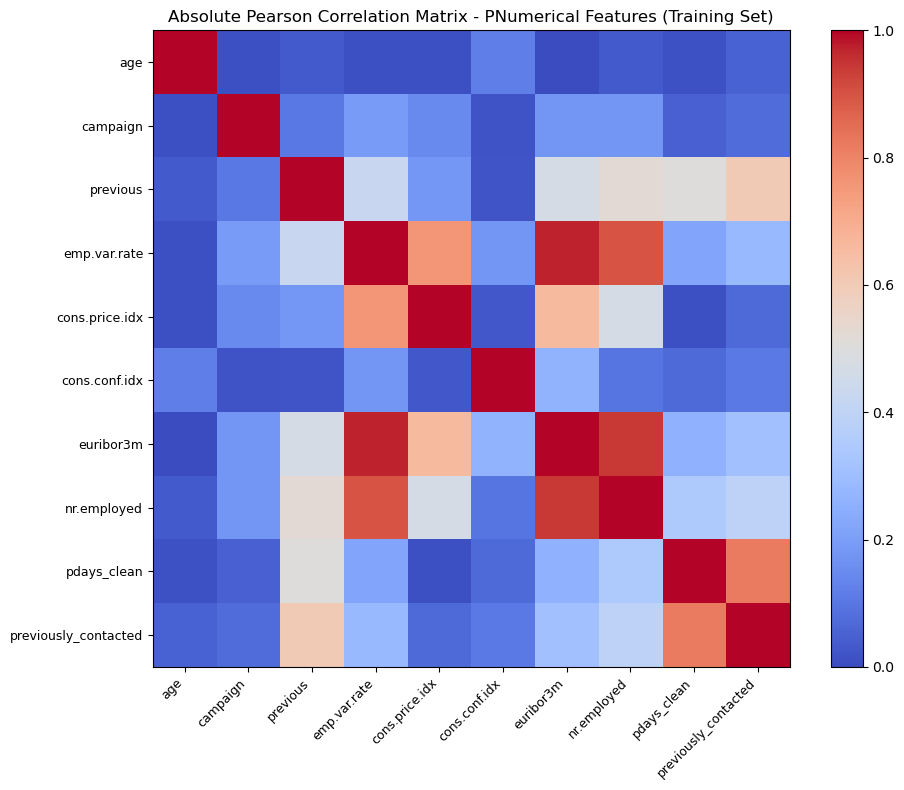

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Select only numerical features from the training set for correlation analysis
numerical_cols = scale_numeric_vars + binary_numeric_vars
corr_matrix = X_train_fs[numerical_cols].corr().abs()

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(numerical_cols)))
ax.set_yticks(range(len(numerical_cols)))
ax.set_xticklabels(numerical_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(numerical_cols, fontsize=9)
ax.set_title("Absolute Pearson Correlation Matrix - PNumerical Features (Training Set)")
plt.tight_layout()
plt.show()

The heatmap visualises the absolute Pearson correlation between all numerical features in the training set. Dark red indicates a strong positive linear relationship (correlation close to 1), while dark blue indicates little to no linear relationship (correlation close to 0).

Several clear patterns emerge from the matrix:

**Macroeconomic cluster:** `emp.var.rate`, `euribor3m`, `nr.employed`, and `cons.price.idx` form a strongly correlated cluster, with pairwise correlations well above 0.85. This confirms the hypothesis raised during EDA: these variables all reflect the same underlying economic environment and move together across the campaign period. Including all of them simultaneously provides highly redundant information to the model.

**`cons.conf.idx`** shows moderate correlations with the macroeconomic cluster but does not exceed the threshold, suggesting it captures a somewhat independent signal, likely reflecting consumer sentiment rather than purely economic activity.

**`pdays_clean` and `previously_contacted`** are strongly correlated with each other (dark red in the bottom-right corner), which is expected: `pdays_clean` is only non-zero when `previously_contacted = 1`, so the two features are structurally linked. 

**`age`, `campaign`, and `previous`** show low correlations with most other features, indicating they contribute relatively independent information and are unlikely to cause multicollinearity issues.

Overall, the heatmap confirms that the main source of redundancy in this dataset lies among the macroeconomic indicators and between the two `pdays`, derived features. These will be addressed in the removal step below.

In [71]:
# Identify pairs of features with absolute correlation above threshold
correlation_threshold = 0.85

# Extract upper triangle to avoid duplicate pairs
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find correlated pairs
correlated_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)
correlated_pairs = correlated_pairs[correlated_pairs["correlation"] > correlation_threshold]
correlated_pairs = correlated_pairs.sort_values("correlation", ascending=False)

print(f"Feature pairs with absolute correlation above {correlation_threshold}:")
print(correlated_pairs.to_string(index=False))

Feature pairs with absolute correlation above 0.85:
   feature_1   feature_2  correlation
emp.var.rate   euribor3m     0.970013
   euribor3m nr.employed     0.941699
emp.var.rate nr.employed     0.896018


The output confirms three pairs of features with absolute correlation above the 0.85 threshold, all involving macroeconomic variables:

- `emp.var.rate` and `euribor3m` have a correlation of 0.97 — an extremely strong linear relationship, meaning these two variables are almost interchangeable from the model's perspective.
- `euribor3m` and `nr.employed` have a correlation of 0.94, again indicating near-redundant information.
- `emp.var.rate` and `nr.employed` have a correlation of 0.90, confirming that all three variables move together as part of the same macroeconomic cluster.

Notably, `pdays_clean` and `previously_contacted` did not exceed the threshold despite being structurally linked. This is because `pdays_clean` contains continuous variation among previously contacted clients, so while the two features are related, they are not fully redundant in a linear sense.

From the three correlated pairs, the removal strategy is to keep the least redundant feature from each pair, specifically the one with the lowest average absolute correlation to all other numerical features. This minimises information loss while eliminating multicollinearity.

In [72]:
# For each correlated pair, remove the feature with higher average correlation to others
features_to_drop_corr = set()

for _, row in correlated_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    # Skip if one has already been marked for removal
    if f1 in features_to_drop_corr or f2 in features_to_drop_corr:
        continue
    # Drop the one with higher mean absolute correlation to all other features
    mean_corr_f1 = corr_matrix[f1].drop(index=f1).mean()
    mean_corr_f2 = corr_matrix[f2].drop(index=f2).mean()
    features_to_drop_corr.add(f1 if mean_corr_f1 > mean_corr_f2 else f2)

print("Features removed due to high correlation:")
print(features_to_drop_corr)

# Remove from all splits
X_train_fs = X_train_fs.drop(columns=list(features_to_drop_corr))
X_val_fs   = X_val_fs.drop(columns=list(features_to_drop_corr))
X_test_fs  = X_test_fs.drop(columns=list(features_to_drop_corr))

print("\nShape after correlation-based removal:")
print("X_train_fs:", X_train_fs.shape)
print("X_val_fs:  ", X_val_fs.shape)
print("X_test_fs: ", X_test_fs.shape)

Features removed due to high correlation:
{'euribor3m', 'emp.var.rate'}

Shape after correlation-based removal:
X_train_fs: (2471, 50)
X_val_fs:   (824, 50)
X_test_fs:  (824, 50)


The algorithm removed `euribor3m` and `emp.var.rate`, retaining `nr.employed` as the representative of the macroeconomic cluster. This is because `nr.employed` had the lowest average absolute correlation to the remaining features, making it the least redundant of the three.

`nr.employed` (number of employees) is a broad macroeconomic indicator that captures the overall state of the labour market during the campaign period. Retaining it preserves the economic signal of the cluster — the general economic climate at the time of contact — without the redundancy introduced by including all three highly correlated variables.

After both the low-variance filter and the correlation-based removal, the feature set has been reduced from the post-encoding dimensionality to 50 features across all three splits. This reduction improves the conditioning of the optimisation problem, reduces the risk of overfitting, and makes regularisation more effective by ensuring that each remaining coefficient reflects a more independent contribution to the prediction.

### Pipeline discipline and conceptual feature removal

Feature selection is not purely a statistical exercise. Beyond variance and correlation, features must also be evaluated on conceptual grounds: whether they are available at prediction time, whether they introduce data leakage, and whether their inclusion is justified given the problem formulation.

In this dataset, the variable `duration` (call duration in seconds) was already excluded at the splitting stage for exactly this reason. It is only known after the call has ended, meaning it would not be available when the model needs to make a prediction, at the time of contact. Including it would produce a model that appears to perform well during evaluation but would be unusable in deployment. This is the most direct form of target leakage in this dataset and was addressed before any preprocessing took place.

All remaining features in the current feature set represent information that is genuinely available at the time of contact: demographic attributes (age, job, marital status, education), financial status (housing loan, personal loan, credit default), campaign-related information (contact type, month, day, number of contacts, prior contact history), and macroeconomic context. None of these require post-contact information to be observed, so no further conceptual removals are necessary.

### Why feature selection must use the training set only

Feature selection decisions, including variance thresholds and correlation thresholds, must be derived exclusively from the training set. This is because feature selection is a data-driven process: variance is estimated from the data, and correlations are computed from the data. If these statistics were computed using the full dataset before splitting, information from the validation and test sets would influence which features are retained, resulting in  data leakage.

The consequence of performing feature selection on the full dataset before splitting would be that the selected feature subset is optimised for the entire data distribution, including the evaluation sets. This means the model would be evaluated on a feature set that was partially chosen based on the test data, producing overly optimistic performance estimates that would not generalise to truly unseen data.

By computing all feature selection criteria on the training set only and applying the resulting decisions consistently to validation and test sets, the pipeline ensures that evaluation remains a genuine test of generalisation rather than a reflection of information the model has already seen.

In [73]:
# Summary of feature selection
print("=== Feature Selection Summary ===")
print(f"Features before selection:     {X_train_processed.shape[1]}")
print(f"Removed (low variance):        {len(low_variance_features)}")
print(f"Removed (high correlation):    {len(features_to_drop_corr)}")
print(f"Features after selection:      {X_train_fs.shape[1]}")
print(f"\nFinal training set shape:   {X_train_fs.shape}")
print(f"Final validation set shape: {X_val_fs.shape}")
print(f"Final test set shape:       {X_test_fs.shape}")
print(f"\nRemaining features:")
print(list(X_train_fs.columns))

=== Feature Selection Summary ===
Features before selection:     56
Removed (low variance):        4
Removed (high correlation):    2
Features after selection:      50

Final training set shape:   (2471, 50)
Final validation set shape: (824, 50)
Final test set shape:       (824, 50)

Remaining features:
['education', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'default_no', 'default_unknown', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_failure', 'poutcome_nonexistent', 'poutcome_succes

## Task 8: Addressing Class Imbalance

Class imbalance occurs when the distribution of the target variable is skewed, with one class substantially more frequent than the other. As identified during exploratory analysis, this dataset exhibits pronounced imbalance: approximately 89% of observations belong to the "no" class and only 11% to the "yes" class.

This imbalance has direct consequences for model training. A Logistic Regression model trained on imbalanced data will be biased toward the majority class, since predicting "no" for every observation already achieves 89% accuracy. The model may therefore fail to learn meaningful patterns for identifying the minority class, which is precisely the class of greatest business interest for our problem.

To address this, a resampling strategy is applied exclusively to the training set. Resampling must never be applied to the validation or test sets, as these must preserve the original class distribution to provide a reliable and realistic estimate of model performance on unseen data that the model will have to use in deployment.

### Quantifying class distribution in the training set

Class counts (training set):
y
no     2200
yes     271
Name: count, dtype: int64

Class proportions (training set):
y
no     0.8903
yes    0.1097
Name: proportion, dtype: float64


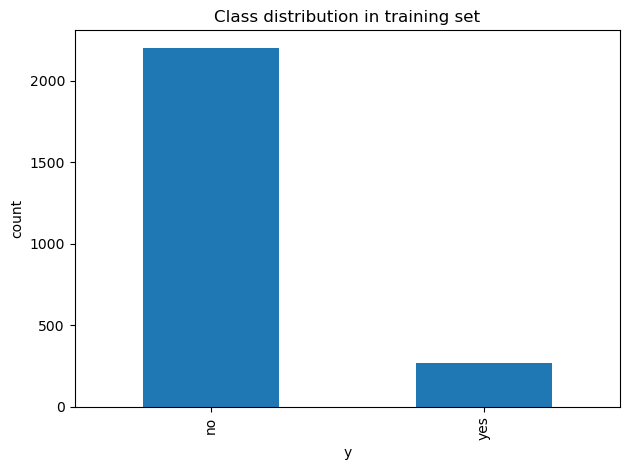

In [74]:
# Quantify class distribution in the training set
train_class_counts = y_train.value_counts()
train_class_props  = y_train.value_counts(normalize=True)

print("Class counts (training set):")
print(train_class_counts)
print("\nClass proportions (training set):")
print(train_class_props.round(4))

# Visualise
train_class_counts.plot(kind="bar")
plt.title("Class distribution in training set")
plt.xlabel("y")
plt.ylabel("count")
plt.tight_layout()
plt.show()

The training set contains 2,200 observations belonging to the "no" class and 271 belonging to the "yes" class, representing proportions of approximately 89% and 11% respectively. This confirms that the class imbalance identified during exploratory analysis is preserved in the training set after stratified splitting, as expected.

The bar chart makes the disparity visually clear: the majority class outnumbers the minority class. This level of imbalance is sufficient to cause a Logistic Regression model to be biased toward predicting "no" by default, since doing so incurs very low training loss. Without intervention, the model is unlikely to learn a meaningful decision boundary for identifying potential subscribers.

### Resampling strategy: SMOTE

To address the class imbalance in the training set, SMOTE (Synthetic Minority Oversampling Technique) is applied. SMOTE generates synthetic observations for the minority class by interpolating between existing minority class examples in the feature space, rather than simply duplicating existing observations.

SMOTE is preferred over random oversampling for several reasons in this context:

- **Random oversampling** duplicates existing minority class observations, which increases the risk of overfitting: the model may memorise specific training examples rather than learning general patterns.
- **SMOTE** creates new synthetic observations by interpolating between a minority class example and its nearest neighbours. This introduces diversity into the minority class, encouraging the model to learn more general decision boundaries.
- SMOTE assumes that the feature space between minority class observations is a plausible region for new examples. This assumption is reasonable for the numerical and encoded features in this dataset.

Importantly, SMOTE is applied **only to the training set**, after splitting. Applying resampling to the validation or test sets would distort their class distribution, making evaluation unreliable. The validation and test sets must preserve the original imbalanced distribution to reflect the real-world conditions under which the model will operate.

In [75]:
from imblearn.over_sampling import SMOTE

# Encode target as binary for resampling
y_train_bin = (y_train == "yes").astype(int)
y_val_bin   = (y_val == "yes").astype(int)
y_test_bin  = (y_test == "yes").astype(int)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fs, y_train_bin)

print("Before SMOTE:")
print("  Class 0 (no): ", (y_train_bin == 0).sum())
print("  Class 1 (yes):", (y_train_bin == 1).sum())

print("\nAfter SMOTE:")
print("  Class 0 (no): ", (y_train_resampled == 0).sum())
print("  Class 1 (yes):", (y_train_resampled == 1).sum())

Before SMOTE:
  Class 0 (no):  2200
  Class 1 (yes): 271

After SMOTE:
  Class 0 (no):  2200
  Class 1 (yes): 2200


After applying SMOTE, the training set is now perfectly balanced: both classes contain 2,200 observations. SMOTE generated 1,929 synthetic minority class examples by interpolating between existing "yes" observations and their nearest neighbours in the feature space.

The validation and test sets remain untouched with their original imbalanced distributions (approximately 89% "no", 11% "yes"), ensuring that evaluation reflects real-world conditions and that performance metrics are not artificially inflated by an unrealistic class balance.

### What would happen if resampling were applied before splitting

If SMOTE were applied to the full dataset before splitting into training, validation, and test sets, two serious problems would arise:

**1. Data leakage:**  If applied before splitting, synthetic observations derived from validation or test set examples could end up in the training set. This means the model would be trained on data that is mathematically related to the evaluation sets, producing artificially optimistic performance estimates that would not generalise to unseen data in deployment.

**2. Unrealistic evaluation:** The validation and test sets would contain synthetic observations that do not reflect the true population distribution. Evaluation metrics computed on these sets would therefore not represent how the model would perform in a real deployment scenario, where the class imbalance mirrors the original dataset.

For these reasons, resampling must always occur after splitting and must be applied exclusively to the training set.

### How class imbalance affects evaluation metrics (Accuracy, Precision, Recall)

**Accuracy:** measures the proportion of correctly classified observations. In imbalanced datasets, accuracy is a misleading metric: a model that always predicts "no" would achieve high accuracy on this dataset despite completely failing to identify any subscriber in our case approximately 89% accuracy. High accuracy can therefore mask poor performance on the minority class.

**Precision:** measures the proportion of predicted subscribers who are actually subscribers (the "yes" class). It answers: "Of all clients the model flags as likely to subscribe, how many truly will?" Low precision means the model generates many false positives, flagging clients who will not subscribe, which will waste marketing resources for example given our business problem.

**Recall** (for the "yes" class) measures the proportion of actual subscribers that the model correctly identifies. It answers: "Of all clients who truly subscribed, how many did the model catch?" A low recall would mean that the model misses many actual subscribers, which is a direct failure of the campaign objective.

In this business context, recall is particularly important: failing to identify a potential subscriber (false negative) represents a missed business opportunity. However, very low precision is also costly, as it leads to inefficient allocation of outreach and marketing resources. The trade-off between precision and recall should therefore be carefully considered when evaluating the model, and accuracy alone should never be used as the primary performance metric.

## Task 9: Training a Logistic Regression Model

Keeping in mind that the purpose of this task is not to maximise predictive performance, but to verify that the data preparation pipeline developed in the previous tasks is coherent and correctly implemented, we will proceed to train a logistic regression model. A Logistic Regression model is trained on the SMOTE-resampled training set and evaluated on the validation set, which preserves the original class distribution, and we could test its performace on the test set to see how it would work in deployment.

Given that the preprocessing pipeline was done keeping data leakage in mind, the model should behave sensibly. Unexpected results at this stage would signal a methodological error in an earlier step rather than a failure of the model itself.

### Why Logistic Regression?

Logistic Regression is the right choice for this binary classification problem for several reasons:

- It is a linear model whose behavior is directly shaped by the preprocessing decisions made in this pipeline. This makes it an ideal sanity check: the quality of the preprocessing is directly reflected in the stability and interpretability of the model's coefficients.
- It produces probabilistic outputs (class probabilities), which are meaningful for business decisions, in our case it could mean prioritising outreach to clients most likely to subscribe.
- It is interpretable: each coefficient reflects the change in log-odds of subscription associated with a one-unit (or one-standard-deviation, after scaling) change in the corresponding feature.
- It is computationally efficient and well-suited to datasets of this size.

### Training set used

The model is trained on `X_train_resampled` and `y_train_resampled`, the SMOTE-balanced training data. As established in the previous stage, SMOTE was applied exclusively to the training set after splitting, ensuring that the validation and test sets reflect the true class distribution of the population.

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, classification_report)

# Train Logistic Regression on the SMOTE-resampled training set
# max_iter=1000 ensures convergence given the dimensionality of the feature space after encoding
# Default L2 regularization (C=1.0) is retained to penalise large coefficients
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_resampled, y_train_resampled)

# Generate predictions on the validation set
# X_val_fs contains the feature-selected, scaled, encoded validation features
# y_val_bin is the binarized validation target (0 = no, 1 = yes)
y_val_pred = log_reg.predict(X_val_fs)

# Compute evaluation metrics on the validation set
accuracy  = accuracy_score(y_val_bin, y_val_pred)
precision = precision_score(y_val_bin, y_val_pred, zero_division=0)
recall    = recall_score(y_val_bin, y_val_pred, zero_division=0)
f1        = f1_score(y_val_bin, y_val_pred, zero_division=0)

print("Validation Set Performance")
print("-" * 32)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Validation Set Performance
--------------------------------
Accuracy:  0.8083
Precision: 0.3090
Recall:    0.6111
F1 Score:  0.4104


In [77]:
print("Classification Report — Validation Set")
print("-" * 50)
print(classification_report(y_val_bin, y_val_pred,
                             target_names=["No (0)", "Yes (1)"],
                             zero_division=0))

Classification Report — Validation Set
--------------------------------------------------
              precision    recall  f1-score   support

      No (0)       0.95      0.83      0.89       734
     Yes (1)       0.31      0.61      0.41        90

    accuracy                           0.81       824
   macro avg       0.63      0.72      0.65       824
weighted avg       0.88      0.81      0.83       824



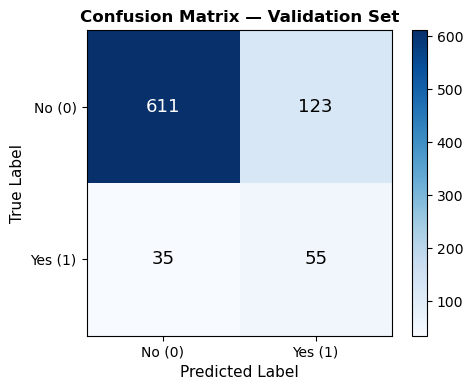


True Negatives  (correctly predicted 'no'):       611
False Positives (predicted 'yes', actually 'no'): 123
False Negatives (predicted 'no', actually 'yes'): 35
True Positives  (correctly predicted 'yes'):      55


In [78]:
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_val_bin, y_val_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

classes = ["No (0)", "Yes (1)"]
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.set_title("Confusion Matrix — Validation Set", fontsize=12, fontweight="bold")

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=13)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted 'no'):       {tn}")
print(f"False Positives (predicted 'yes', actually 'no'): {fp}")
print(f"False Negatives (predicted 'no', actually 'yes'): {fn}")
print(f"True Positives  (correctly predicted 'yes'):      {tp}")

### Validation Set Performance: Full Classification Report

The Logistic Regression model was evaluated on the validation set, which was kept completely unseen during training and resampling. The validation set preserves the original imbalanced class distribution (89% "no" and 11% "yes"), ensuring that evaluation reflects real-world conditions the model would face later on in deployment.

#### Per-class and averaged metrics

| Class / Average  | Precision | Recall | F1 Score | Support |
|------------------|-----------|--------|----------|---------|
| No (0)           | 0.9459    | 0.8311 | 0.8847   | 734     |
| Yes (1)          | 0.3090    | 0.6111 | 0.4154   | 90      |
| Macro Average    | 0.6275    | 0.7211 | 0.6500   | 824     |
| Weighted Average | 0.8800    | 0.8083 | 0.8388   | 824     |

The confusion matrix shows the full breakdown of predictions:

- **611 True Negatives**: clients correctly predicted as non-subscribers.
- **55 True Positives**: actual subscribers correctly identified by the model.
- **123 False Positives**: clients incorrectly flagged as subscribers (predicted "yes", actually "no").
- **35 False Negatives**: actual subscribers missed by the model (predicted "no", actually "yes").

#### Macro vs weighted average

The **macro average** treats both classes equally regardless of their size, it is the unweighted mean of each metric across classes. It is particularly informative here because it gives equal weight to the minority class ("yes"), whose performance would otherwise be drowned out by the majority class in a weighted calculation. The macro F1 of 0.65 reflects a more honest picture of how the model performs across both classes.

The **weighted average** weights each class's metric by its number of observations (support). 
Because the "no" class dominates with 734 out of 824 observations, the weighted averages are pulled strongly toward the majority class performance and should not be used as the primary indicator of model quality in this imbalanced setting.

### Zero Rule Baseline Comparison and Interpretation

The Zero Rule baseline is the simplest possible classifier: it always predicts the majority class regardless of any input features. In this dataset, approximately 89.1% of clients did not subscribe. A Zero Rule classifier would therefore predict "no" for every single observation, 
achieving:

| Metric           | Zero Rule | Logistic Regression |
|------------------|-----------|---------------------|
| Accuracy         | 0.8911    | 0.8083              |
| Precision (yes)  | 0.0000    | 0.3090              |
| Recall (yes)     | 0.0000    | 0.6111              |
| F1 Score (yes)   | 0.0000    | 0.4154              |
| Macro F1         | 0.0000    | 0.6500              |
| Weighted F1      | 0.0000    | 0.8388              |

#### Direct comparison and interpretation

**Accuracy:** The Logistic Regression scores 80.83%, which is lower than the Zero Rule's 89.11%. At first glance this looks like a worse model, but in reality it is not. The Zero Rule achieves its high accuracy purely by exploiting class imbalance, it never predicts a single subscriber, so it is correct 89% of the time simply because 89% of clients genuinely did not subscribe. There is no learning. The Logistic Regression however, scores lower on accuracy precisely because it has learned to predict "yes" in some cases. So analiticaly  drop in accuracy relative to the Zero Rule baseline is therefore not a failure; it is evidence that the model is actually attempting to learn the minority class.

**Precision (yes class):** The Zero Rule has precision of 0 for the "yes" class because it never predicts "yes" at all, there are no true positives and no false positives. The Logistic Regression achieves a precision of 0.3090, meaning that roughly 1 in 3 clients it flags as likely subscribers actually is one. This is a meaningful signal: the model has learned that certain combinations of features are genuinely associated with subscription, even if it also generates false alarms in some cases.

**Recall (yes class):** The Zero Rule has a recall of exactly 0 for the "yes" class, this means that it misses every single subscriber in the validation set, because there is no true learning, it just predicts the majority class. The Logistic Regression correctly identifies 55 out of 90 actual subscribers, achieving a recall of 0.6111. This is the most important improvement over the baseline in this business context: the model catches 61% of potential subscribers that the Zero Rule would have completely ignored, directly supporting the campaign objective.

**F1 Score (yes class):** The Zero Rule scores 0 on F1 because it has zero recall. The Logistic Regression scores 0.4154, reflecting a meaningful but imperfect balance between precision and recall. This gap (from 0 to 0.4154) is the clearest single-number summary of what the full preprocessing pipeline has achieved: the model has gone from being completely blind to the minority class to correctly capturing over 60% of it, at the cost of some false positives.

**Macro F1:** The macro F1 rises from 0 under the Zero Rule to 0.65 under the Logistic Regression. Like the macro average gives equal weight to both classes, this improvement confirms that the model is performing meaningfully on both "no" and "yes" — not just on the majority class. This is the most balanced summary metric for evaluating a classifier in an imbalanced setting.

**Weighted F1:** The weighted F1 of 0.8388 is high because it is dominated by the majority class ("no"), which the model predicts well. This metric should not be interpreted in isolation as it masks the lower performance on the minority class. It is included for completeness but the macro F1 and the per-class metrics for "yes" are more informative for this problem.

#### Pipeline consistency check

The results are consistent with a correctly implemented pipeline:

- The model does not collapse to always predicting one class. Both "yes" and "no" are predicted, confirming the SMOTE-balanced training had the intended effect.
- Recall for the minority class is non-trivial (61%), confirming that the feature engineering, 
encoding, scaling, and feature selection steps produced informative input representations.
- The drop in accuracy relative to the Zero Rule is expected and explainable. It is the result of training on balanced data and evaluating on imbalanced data, not a symptom of data leakage or a pipeline error.
- The macro F1 improvement from 0 to 0.65 confirms the model has learned genuine signal from both classes, not just the majority.

Overall, the model behaves sensibly. The pipeline is coherent.

## Some more visualizations

## Design choices & alternative approaches